In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import PIL
import random
import seaborn as sns
from pathlib import Path
import cv2


In [2]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

set_seed(42)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define paths
DATA_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\data\processed"
TRAIN_DIR = os.path.join(DATA_ROOT, "TRAIN")
VAL_DIR = os.path.join(DATA_ROOT, "VALIDATION")
TEST_DIR = os.path.join(DATA_ROOT, "TEST")

# Create output directory
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define class labels
classes = ['SOBER', 'DRUNK']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}


Random seed set to 42
Using device: cuda:0


In [3]:
# ====================== DATA EXPLORATION ======================

def explore_dataset(data_dir, title):
    """Explore the dataset and visualize class distribution."""
    class_counts = {cls: 0 for cls in classes}
    file_paths = []
    labels = []
    
    for class_name in classes:
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))]
            class_counts[class_name] = len(files)
            
            for file in files:
                file_paths.append(os.path.join(class_path, file))
                labels.append(class_to_idx[class_name])
    
    # Print statistics
    print(f"\n{title} Dataset Statistics:")
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} samples")
    print(f"  Total: {sum(class_counts.values())} samples")
    
    # Plot class distribution
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.title(f"{title} Dataset Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    for i, count in enumerate(class_counts.values()):
        plt.text(i, count + 5, str(count), ha='center')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{title.lower()}_class_distribution.png"))
    plt.close()
    
    return file_paths, labels, class_counts

# Explore all datasets
train_files, train_labels, train_counts = explore_dataset(TRAIN_DIR, "Training")
val_files, val_labels, val_counts = explore_dataset(VAL_DIR, "Validation")
test_files, test_labels, test_counts = explore_dataset(TEST_DIR, "Test")


Training Dataset Statistics:
  SOBER: 5189 samples
  DRUNK: 2281 samples
  Total: 7470 samples

Validation Dataset Statistics:
  SOBER: 3741 samples
  DRUNK: 1573 samples
  Total: 5314 samples

Test Dataset Statistics:
  SOBER: 2187 samples
  DRUNK: 1858 samples
  Total: 4045 samples


In [4]:
# ====================== DATA VISUALIZATION ======================

def visualize_spectrograms(file_paths, labels, num_samples=5, save_path=None):
    """Visualize sample spectrograms from each class"""
    # Get sample images from each class
    samples_by_class = {cls: [] for cls in classes}
    for path, label in zip(file_paths, labels):
        class_name = idx_to_class[label]
        if len(samples_by_class[class_name]) < num_samples:
            samples_by_class[class_name].append(path)
    
    # Create subplot grid
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 5))
    
    for i, class_name in enumerate(classes):
        for j, img_path in enumerate(samples_by_class[class_name]):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_name}")
            axes[i, j].axis('off')
    
    plt.suptitle("Sample Spectrogram Images")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.close()

# Visualize sample spectrograms
visualize_spectrograms(
    train_files, 
    train_labels, 
    num_samples=5, 
    save_path=os.path.join(OUTPUT_DIR, "sample_spectrograms.png")
)

In [5]:
#Dataset Class
class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['SOBER', 'DRUNK']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.samples = self._make_dataset()
        
    def _make_dataset(self):
        samples = []
        for class_name in os.listdir(self.root_dir):
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                class_idx = self.class_to_idx[class_name]
                for filename in os.listdir(class_path):
                    if filename.endswith(('.jpg', '.jpeg', '.png')):
                        samples.append((
                            os.path.join(class_path, filename),
                            class_idx
                        ))
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label



In [6]:
# Data Preparation
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize datasets

train_dataset = SpectrogramDataset(TRAIN_DIR, transform)
val_dataset = SpectrogramDataset(VAL_DIR, transform)
test_dataset = SpectrogramDataset(TEST_DIR, transform)

# Create balanced sampler
class_counts = torch.tensor([len([x for x in train_dataset.samples if x[1] == i]) for i in range(2)])
class_weights = 1. / class_counts
class_weights = class_weights / class_weights.sum()  # Normalize
sample_weights = torch.tensor([class_weights[y] for _, y in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create data loaders
BATCH_SIZE = 100
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
def resnet18_classifier():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze deeper layers for fine-tuning
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace classifier head
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 1)  # Output for binary classification
    )

    return model.to(device)


In [8]:
# ====================== TRAINING SETUP ======================
model = resnet18_classifier()

# Use class distribution from training data to set pos_weight
# train_counts = {'SOBER': 5189, 'DRUNK': 2281}
pos_weight = torch.tensor([train_counts['SOBER'] / train_counts['DRUNK']]).to(device)

# Use BCEWithLogitsLoss with pos_weight to handle imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer for fine-tuned layers only
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler — Reduce on plateau (e.g., validation loss)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

# Training control
patience = 10   # Early stopping patience
num_epochs = 30

print("\nTraining setup:")
print("Model: ResNet18 pretrained")
print("Optimizer: Adam(lr=0.001, weight_decay=1e-4)")
print("LR scheduler: ReduceLROnPlateau (on val loss)")
print(f"Using pos_weight = {pos_weight.item():.4f}")


Training setup:
Model: ResNet18 pretrained
Optimizer: Adam(lr=0.001, weight_decay=1e-4)
LR scheduler: ReduceLROnPlateau (on val loss)
Using pos_weight = 2.2749


c:\Users\krevi\AppData\Local\anaconda3\envs\torch-env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [9]:


# Evaluation Function
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()
            
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate UAR (Unweighted Average Recall)
    cm = confusion_matrix(all_labels, all_preds)
    if cm.shape == (2, 2):  # binary classification
        tn, fp, fn, tp = cm.ravel()
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        uar = (tpr + tnr) / 2
    else:  # handle case when one class is missing in predictions
        uar = accuracy_score(all_labels, all_preds)  # fallback
    
    metrics = {
        'loss': running_loss / len(data_loader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'uar': uar,
        'confusion_matrix': cm
    }
    
    return metrics


Epoch 1/30
----------


Training: 100%|██████████| 75/75 [00:34<00:00,  2.20it/s]


Train Loss: 0.8704 | Val Loss: 1.1837
Train Acc: 0.6739 | Val Acc: 0.5713
Train UAR: 0.6738 | Val UAR: 0.6040
Validation Confusion Matrix:
[[1960 1781]
 [ 497 1076]]
Saved new best model (based on UAR)!

Epoch 2/30
----------


Training: 100%|██████████| 75/75 [00:21<00:00,  3.44it/s]


Train Loss: 0.6196 | Val Loss: 1.1821
Train Acc: 0.8143 | Val Acc: 0.6468
Train UAR: 0.8142 | Val UAR: 0.6379
Validation Confusion Matrix:
[[2468 1273]
 [ 604  969]]
Saved new best model (based on UAR)!

Epoch 3/30
----------


...

Train Loss: 0.0140 | Val Loss: 3.2413
Train Acc: 0.9971 | Val Acc: 0.6833
Train UAR: 0.9970 | Val UAR: 0.6014
Validation Confusion Matrix:
[[3001  740]
 [ 943  630]]
No improvement in UAR for 8/10 epochs

Epoch 11/30
----------


Training: 100%|██████████| 75/75 [00:13<00:00,  5.53it/s]


Train Loss: 0.0097 | Val Loss: 3.6149
Train Acc: 0.9980 | Val Acc: 0.6921
Train UAR: 0.9980 | Val UAR: 0.5940
Validation Confusion Matrix:
[[3122  619]
 [1017  556]]
No improvement in UAR for 9/10 epochs

Epoch 12/30
----------


Training: 100%|██████████| 75/75 [00:13<00:00,  5.52it/s]


Train Loss: 0.0036 | Val Loss: 3.3821
Train Acc: 0.9997 | Val Acc: 0.6807
Train UAR: 0.9997 | Val UAR: 0.6091
Validation Confusion Matrix:
[[2935  806]
 [ 891  682]]
No improvement in UAR for 10/10 epochs

Early stopping triggered after 10 epochs without improvement!

Training completed. Loaded best model weights.


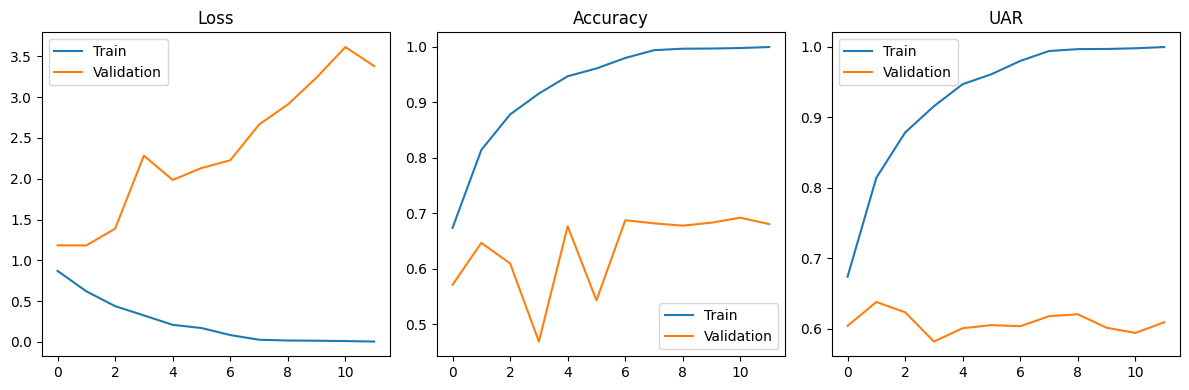


Final Test Results:
Accuracy: 0.6133
UAR: 0.6155
Confusion Matrix:
[[1289  898]
 [ 666 1192]]


In [10]:
# Training Loop with Early Stopping
def train_model(model, train_loader, val_loader, num_epochs, patience):
    best_uar = 0
    no_improvement = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_uar': [], 'val_uar': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)
        
        # Training phase
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device).float()
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        # Calculate training metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Calculate training UAR
        train_cm = confusion_matrix(train_labels, train_preds)
        if train_cm.shape == (2, 2):
            tn, fp, fn, tp = train_cm.ravel()
            tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            train_uar = (tpr + tnr) / 2
        else:
            train_uar = train_acc
        
        # Validation phase
        val_metrics = evaluate(model, val_loader)
        
        # Update LR scheduler
        # scheduler.step()
        scheduler.step(val_metrics['loss'])
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_uar'].append(train_uar)
        history['val_uar'].append(val_metrics['uar'])
        
        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Train UAR: {train_uar:.4f} | Val UAR: {val_metrics['uar']:.4f}")
        print("Validation Confusion Matrix:")
        print(val_metrics['confusion_matrix'])
        
        # Early stopping check
        if val_metrics['uar'] > best_uar:
            best_uar = val_metrics['uar']
            no_improvement = 0
            torch.save(model.state_dict(), "output/best_model.pth")
            print("Saved new best model (based on UAR)!")
        else:
            no_improvement += 1
            print(f"No improvement in UAR for {no_improvement}/{patience} epochs")
            
            if no_improvement >= patience:
                print(f"\nEarly stopping triggered after {patience} epochs without improvement!")
                break
    
    # Load the best model weights before returning
    model.load_state_dict(torch.load("output/best_model.pth"))
    print("\nTraining completed. Loaded best model weights.")
    
    return history

# Train the model with early stopping
history = train_model(
    model, 
    train_loader, 
    val_loader, 
    num_epochs,
    patience  # Stop if no improvement for 10 epochs
)


# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['train_uar'], label='Train')
plt.plot(history['val_uar'], label='Validation')
plt.title('UAR')
plt.legend()

plt.tight_layout()
plt.savefig("output/training_curves.png")
plt.show()
# ======== END VISUALIZATION ========

# Load best model and evaluate on test set
model.load_state_dict(torch.load("output/best_model.pth"))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])


Final Test Results:
Loss: 1.2600
Accuracy: 0.6133
UAR: 0.6155
Confusion Matrix:
[[1289  898]
 [ 666 1192]]


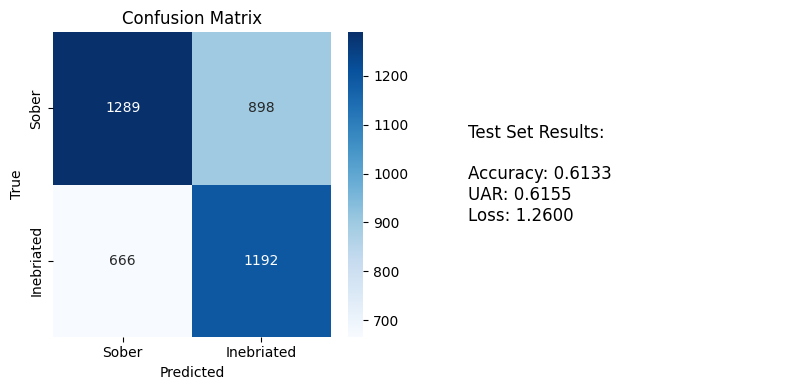

In [11]:
def plot_results(metrics, class_names):
    plt.figure(figsize=(8, 4))
    
    # Confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', 
                cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    # Metrics summary
    plt.subplot(1, 2, 2)
    plt.axis('off')
    metrics_text = (
        "Test Set Results:\n\n"
        f"Accuracy: {metrics['accuracy']:.4f}\n"
        f"UAR: {metrics['uar']:.4f}\n"
        f"Loss: {metrics['loss']:.4f}\n"
    )
    plt.text(0.1, 0.5, metrics_text, fontsize=12, va='center')
    
    plt.tight_layout()
    plt.savefig("output/test_results.png")
    plt.show()

# Load best model and evaluate
model.load_state_dict(torch.load("output/best_model.pth"))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])

# Plot results
plot_results(test_metrics, ['Sober', 'Inebriated'])  # Replace with your actual class names
